
<center>

# Hierarchical Clustering of Kenyan County Health Statistics

##### **Programme:** Master of Science in Artificial Intelligence
##### **Course:** CSA 806 - Data Mining and Big Data
##### **Module:** Module 7 Clustering
##### **Name:** Marrion Kiprop Cherop
##### **Reg Number:** ST62/80971/2024
</center>



## Introduction

I used a county-level subset of 10 Kenyan counties manually compiled from the Kenya County Fact Sheets, Second Edition (June 2013). The fact sheets report county health indicators such as fully immunized children under 1 year, malaria burden, TB cases per 100,000 people, HIV prevalence, and service coverage, and the publication notes HMIS as one of the underlying health data sources. 

## Preprocessing and clustering steps

The analysis followed these steps:

1) Selected five county-level health variables:  
        a) fully immunized population under 1 year (%)  
        b) malaria burden (%)  
        c) TB cases per 100,000 people  
        d) HIV prevalence (%)  
        e)facility delivery / delivered in a health centre (%)    
2) Cleaned the data and arranged one row per county.  
3) Standardized the variables using z-scores so that variables measured on different scales, such as TB cases and immunization percentages, contributed fairly to clustering.  
4) Applied agglomerative hierarchical clustering using Ward linkage, which groups counties by minimizing within-cluster variance.  
5) Used the dendrogram and silhouette scores to choose the number of clusters.  


## Python Code for the Aglomerate Clustering

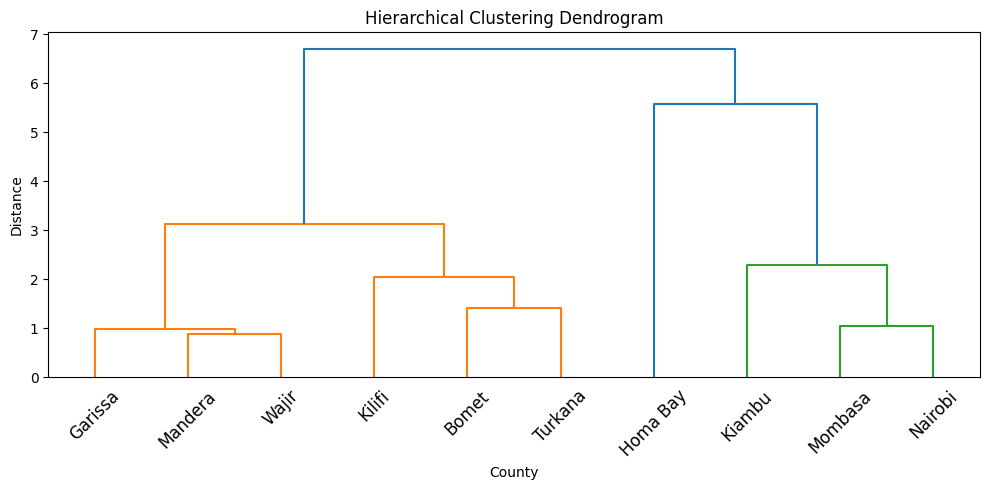

k=2, silhouette=0.386
k=3, silhouette=0.447
k=4, silhouette=0.363
k=5, silhouette=0.315
     County  Cluster
0     Bomet        0
1   Garissa        0
2  Homa Bay        2
3    Kiambu        1
4    Kilifi        0
5   Mandera        0
6   Mombasa        1
7   Nairobi        1
8   Turkana        0
9     Wajir        0


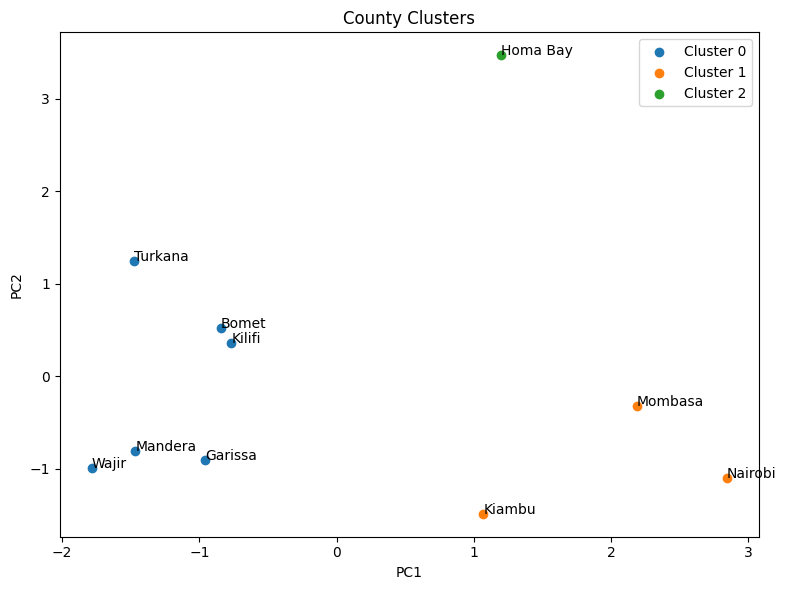

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# County subset compiled from Kenya County Fact Sheets
df = pd.DataFrame([
    ["Bomet", 30.4, 154.4, 279, 3.5, 34.8],
    ["Garissa", 57.8, 31.3, 145, 2.6, 25.1],
    ["Homa Bay", 49.3, 359.7, 453, 27.1, 39.8],
    ["Kiambu", 88.7, 30.0, 259, 4.4, 68.9],
    ["Kilifi", 64.9, 211.3, 231, 3.7, 13.6],
    ["Mandera", 67.1, 84.4, 63, 1.3, 8.2],
    ["Mombasa", 83.8, 79.5, 554, 11.1, 68.9],
    ["Nairobi", 97.0, 26.3, 639, 8.6, 78.9],
    ["Turkana", 27.4, 165.7, 207, 9.9, 6.9],
    ["Wajir", 53.1, 25.4, 86, 0.2, 5.1],
], columns=[
    "County", "Fully_Immunized_U1", "Malaria_Burden",
    "TB_Cases_per_100k", "HIV_Prevalence", "Facility_Delivery"
])

# Standardize
X = df.drop(columns=["County"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dendrogram
Z = linkage(X_scaled, method="ward")
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=df["County"].tolist(), leaf_rotation=45)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("County")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Check best number of clusters
for k in range(2, 6):
    labels = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette={score:.3f}")

# Final model
model = AgglomerativeClustering(n_clusters=3, linkage="ward")
df["Cluster"] = model.fit_predict(X_scaled)
print(df[["County", "Cluster"]])

# 2D visualization using PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
for c in sorted(df["Cluster"].unique()):
    subset = df[df["Cluster"] == c]
    idx = subset.index
    plt.scatter(coords[idx, 0], coords[idx, 1], label=f"Cluster {c}")
    for i in idx:
        plt.annotate(df.loc[i, "County"], (coords[i, 0], coords[i, 1]))
plt.title("County Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()


## Optimal number of clusters

The silhouette scores were:
```
2 clusters: 0.386  
3 clusters: 0.447  
4 clusters: 0.363  
5 clusters: 0.315 
```

The best result was 3 clusters, so the final interpretation uses three groups.

## Cluster results

The counties grouped as follows:

Cluster 0 - Bomet, Garissa, Kilifi, Mandera, Turkana, Wajir

Cluster 1 - Kiambu, Mombasa, Nairobi

Cluster 2 - Homa Bay

This can be intepreted as follows; 

Cluster 0 - Mixed but generally lower service coverage and weaker outcomes on some indicators  
Cluster 1 - Higher immunization and facility delivery, relatively stronger service access  
Cluster 2 - A clear high-burden outlier, especially for malaria and HIV  

## Interpretation of the dendrogram and clusters

The dendrogram shows that Kiambu, Nairobi, and Mombasa are relatively close to one another. These counties have high immunization and high facility delivery, which suggests stronger health service access and uptake. Homa Bay stands apart from the other counties. Its shows very high malaria burden and the highest HIV prevalence among the counties in this subset, which explains why it separated into its own cluster.

The counties in Cluster 0 are more heterogeneous, but they share weaker performance in at least one major dimension such as low facility delivery, lower immunization, or infrastructure and access constraints. Counties such as Turkana, Mandera, and Wajir especially show very low facility delivery levels in the fact sheets.

## Actionable insights

For Cluster 1 (Kiambu, Nairobi, Mombasa) - These counties appear relatively stronger in service uptake. Policy attention here should focus on:

a) sustaining immunization coverage  
b) improving disease surveillance for TB and HIV  
c) targeting dense urban settlements where averages may hide internal inequality  

For Cluster 0 (Bomet, Garissa, Kilifi, Mandera, Turkana, Wajir) - These counties need stronger frontline service delivery. Priority actions include:

a) increasing outreach immunization  
b) improving maternal referral systems and skilled birth attendance  
c) strengthening county-level primary care access in remote and underserved areas  
d) using mobile clinics and community health workers where distance is a barrier  

For Cluster 2 (Homa Bay) - This county needs a more specialized response because it behaves like a high-burden outlier:

a) integrate HIV, TB, and malaria programming  
b) strengthen prevention plus early testing and treatment  
c) prioritize county-specific resource allocation rather than treating it as average  

## Conclusion

Agglomerative hierarchical clustering showed that the counties in this subset do not form one uniform health profile. Instead, they separate into a relatively stronger service-access group, a broader group with weaker or uneven health outcomes, and a high-burden outlier.

In [1]:
import geopandas as gpd
import folium

# Load your GeoJSON polygon
polygon_gdf = gpd.read_file("/home/langstkip/workspace/Adaptive-Probab-OUKresearch/Datasets/boundaries/elgeyo_marakwet_county.geojson")

# Center map on polygon centroid
center = polygon_gdf.geometry.centroid.iloc[0]
m = folium.Map(location=[center.y, center.x], zoom_start=9, tiles="CartoDB positron")

# Add polygon to map
folium.GeoJson(
    polygon_gdf,
    name="Elgeyo-Marakwet County",
    style_function=lambda x: {
        "color": "green",
        "weight": 2,
        "fillOpacity": 0.2
    }
).add_to(m)

folium.LayerControl().add_to(m)
m.save("emc_polygon_map.html")


/tmp/ipykernel_56055/2224826727.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center = polygon_gdf.geometry.centroid.iloc[0]
